### Libraries

In [ ]:
import logging
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from investment_lab.data.option_db import OptionLoader, extract_spot_from_options
from investment_lab.data.rates_db import USRatesLoader
from investment_lab.rates import compute_forward

from investment_lab.surface.reference_iv import (
    SVIReferenceIVExtractor,
    SSVIReferenceIVExtractor,
)

from investment_lab.stochastic.heston_ssm import HestonStateSpaceModel

from investment_lab.signals.implied_realized_spread import build_implied_realized_spread
from investment_lab.signals.allocation import build_zscore_allocation_signal

from investment_lab.option_trade import VarianceSwap
from investment_lab.backtest import BacktesterBidAskFromData
from investment_lab.strategies.dynamic_allocation import DynamicAllocationOverlay

from investment_lab.metrics.performance import evaluate_backtest 
from investment_lab.signals.naive_spread import build_naive_implied_realized_spread

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)

### Inputs

In [ ]:
TICKER = "AAPL"

START_DATE = datetime(2020, 1, 2)
END_DATE = datetime(2022, 12, 30)

TARGET_DTE = 30
TARGET_MONEYNESS = 1.0

ROLLING_WINDOW = 252
FORECAST_HORIZON_DAYS = 30

USE_SURFACE_MODEL = "SSVI"   

ZSCORE_ROLLING_WINDOW = 252
MIN_ALLOCATION = -1.0
MAX_ALLOCATION = 1.0
ZSCORE_SCALING = 1.0
ZSCORE_CENTER = 0.0


### Load data

In [5]:
df_options = OptionLoader.load_data(
    start_date=START_DATE,
    end_date=END_DATE,
    process_kwargs={"ticker": TICKER},
)

df_options = df_options.sort_values(["date", "expiration", "strike"]).reset_index(drop=True)
df_options.head()

2026-04-05 20:42:26,124 - INFO - Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-04-05 20:43:49,519 - INFO - Processing with {'ticker': 'AAPL'}
2026-04-05 20:43:49,605 - INFO - Potentially add extra field with None


,spot,strike,expiration,delta,gamma,vega,theta,rho,implied_volatility,bid,ask,volume,call_put,option_id,mid,ticker,date,day_to_expiration,moneyness
0,300.35,200.0,2020-01-03,1.00000,0.00000,0.00000,-0.00002,0.01084,0.00000,98.4,101.80,2.0,C,AAPL 20200103C200,100.100,AAPL,2020-01-02,1,0.665890
1,300.35,200.0,2020-01-03,-0.00002,0.00004,0.00023,-0.00477,0.00000,1.70088,0.0,0.01,0.0,P,AAPL 20200103P200,0.005,AAPL,2020-01-02,1,0.665890
2,300.35,205.0,2020-01-03,1.00000,0.00000,0.00000,-0.00030,0.01162,0.00000,93.4,97.00,2.0,C,AAPL 20200103C205,95.200,AAPL,2020-01-02,1,0.682537
3,300.35,205.0,2020-01-03,-0.00046,0.00004,0.00041,-0.00515,-0.00005,1.60352,0.0,0.02,5.0,P,AAPL 20200103P205,0.010,AAPL,2020-01-02,1,0.682537
4,300.35,210.0,2020-01-03,1.00000,0.00000,0.00000,-0.00043,0.01156,0.00000,88.4,92.20,4.0,C,AAPL 20200103C210,90.300,AAPL,2020-01-02,1,0.699184


In [6]:
df_rates = USRatesLoader.load_data(
    start_date=max(START_DATE, datetime(2020, 1, 2)),
    end_date=END_DATE,
)

df_options = compute_forward(df_options=df_options, df_rates=df_rates)
df_options.head()

2026-04-05 20:44:09,705 - INFO - Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/par-yield-curve-rates-2020-2023.csv with None
2026-04-05 20:44:09,846 - INFO - Processing with None
2026-04-05 20:44:09,846 - INFO - Potentially add extra field with None
C:\Users\33761\OneDrive - CentraleSupelec\Documents\Cours 4A\Stratégie de la volatilité\Code\Dauphine-Lecture-Volatility\investment_lab\rates.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_values)


,spot,strike,expiration,delta,gamma,vega,theta,rho,implied_volatility,bid,...,volume,call_put,option_id,mid,ticker,date,day_to_expiration,moneyness,risk_free_rate,forward
0,300.35,200.0,2020-01-03,1.00000,0.00000,0.00000,-0.00002,0.01084,0.00000,98.40,...,2.0,C,AAPL 20200103C200,100.100,AAPL,2020-01-02,1,0.665890,0.015300,300.362582
1,300.35,185.0,2020-07-17,0.90372,0.00042,0.27391,-0.03082,0.21555,0.47458,114.51,...,0.0,C,AAPL 20200717C185,116.530,AAPL,2020-01-02,197,0.615948,0.015692,302.902846
2,300.35,180.0,2020-07-17,-0.02316,0.00065,0.11854,-0.01092,-0.04076,0.37133,0.66,...,33.0,P,AAPL 20200717P180,0.765,AAPL,2020-01-02,197,0.599301,0.015692,302.902846
3,300.35,180.0,2020-07-17,0.90131,0.00036,0.26977,-0.03235,0.19211,0.50030,119.41,...,0.0,C,AAPL 20200717C180,121.400,AAPL,2020-01-02,197,0.599301,0.015692,302.902846
4,300.35,175.0,2020-07-17,-0.02013,0.00059,0.10690,-0.01054,-0.03629,0.38181,0.58,...,1.0,P,AAPL 20200717P175,0.685,AAPL,2020-01-02,197,0.582654,0.015692,302.902846


In [7]:
df_spot = extract_spot_from_options(df_options).copy()
df_spot["ticker"] = TICKER
df_spot = df_spot.sort_values("date").reset_index(drop=True)
df_spot["log_spot"] = np.log(df_spot["spot"])
df_spot["log_return"] = df_spot["log_spot"].diff()
df_spot.head()

,date,spot,ticker,log_spot,log_return
0,2020-01-02,300.35,AAPL,5.704948,NaN
1,2020-01-03,297.43,AAPL,5.695179,-0.009770
2,2020-01-06,299.80,AAPL,5.703116,0.007937
3,2020-01-07,298.39,AAPL,5.698401,-0.004714
4,2020-01-08,303.19,AAPL,5.714360,0.015958


### Implied vol

In [23]:
if USE_SURFACE_MODEL.upper() == "SVI":
    iv_extractor = SVIReferenceIVExtractor(
        target_day_to_expiration=TARGET_DTE,
        target_moneyness=TARGET_MONEYNESS,
        minimum_points_per_expiry=5,
    )
elif USE_SURFACE_MODEL.upper() == "SSVI":
    iv_extractor = SSVIReferenceIVExtractor(
        target_day_to_expiration=TARGET_DTE,
        target_moneyness=TARGET_MONEYNESS,
        minimum_points_per_expiry=5,
    )
else:
    raise ValueError("USE_SURFACE_MODEL must be 'SVI' or 'SSVI'.")

df_iv_reference = iv_extractor.extract(df_options)
df_iv_reference.head()

2026-04-05 19:55:21,739 - INFO - Extracting reference IV on 1537148 option rows.
2026-04-05 19:55:23,744 - INFO - After filtering: 1419855 rows remaining.
2026-04-05 19:55:24,066 - INFO - Fitting SSVI model on 83 records
2026-04-05 19:55:24,080 - INFO - Successfully fitted SSVI. Parameters: [ 0.2 -0.3  0.5  0.2]
2026-04-05 19:55:24,081 - INFO - Fitting SSVI model on 105 records
2026-04-05 19:55:24,097 - INFO - Successfully fitted SSVI. Parameters: [ 0.31171528 -0.55180645  0.94310137  0.49103294]
2026-04-05 19:55:24,099 - INFO - Fitting SSVI model on 142 records
2026-04-05 19:55:24,112 - INFO - Successfully fitted SSVI. Parameters: [ 0.14957269 -0.74575256  4.62534148  0.5       ]
2026-04-05 19:55:24,118 - INFO - Fitting SSVI model on 120 records
2026-04-05 19:55:24,129 - INFO - Successfully fitted SSVI. Parameters: [ 0.28519644 -0.51443151  0.81865269  0.5       ]
2026-04-05 19:55:24,133 - INFO - Fitting SSVI model on 118 records
2026-04-05 19:55:24,145 - INFO - Successfully fitted SS

KeyboardInterrupt: 

### Heston state space model

In [ ]:
heston_ssm = HestonStateSpaceModel(
    rolling_window=ROLLING_WINDOW,
    forecast_horizon_days=FORECAST_HORIZON_DAYS,
    measurement_error=1e-6,
    variance_proxy_error=0.01,
    rv_proxy_window=5,
)

df_heston = heston_ssm.rolling_fit_predict(
    df_spot[["date", "spot"]],
    recalibration_frequency=5,   
)
df_heston["ticker"] = TICKER

2026-04-05 20:44:41,337 - INFO - Diffusion params (moments): xi=3.000, rho=-0.678, mu=-0.500 | Initial kappa=5.00, theta=0.1298 (vol=36.0%)


2026-04-05 20:45:04,023 - INFO - Hybrid calibrated: kappa=5.000, theta=2.0000 (vol=141.4%) | fixed xi=3.000, rho=-0.678 | NLL=-98.40
2026-04-05 20:45:04,028 - INFO - Diffusion params (moments): xi=3.000, rho=-0.678, mu=-0.500 | Initial kappa=5.00, theta=0.1338 (vol=36.6%)
2026-04-05 20:45:48,842 - INFO - Hybrid calibrated: kappa=5.000, theta=2.0000 (vol=141.4%) | fixed xi=3.000, rho=-0.678 | NLL=-96.28
2026-04-05 20:45:48,850 - INFO - Diffusion params (moments): xi=3.000, rho=-0.678, mu=-0.500 | Initial kappa=5.00, theta=0.1338 (vol=36.6%)
2026-04-05 20:46:17,352 - INFO - Hybrid calibrated: kappa=5.000, theta=2.0000 (vol=141.4%) | fixed xi=3.000, rho=-0.678 | NLL=-93.41
2026-04-05 20:46:17,361 - INFO - Diffusion params (moments): xi=3.000, rho=-0.678, mu=-0.500 | Initial kappa=5.00, theta=0.1321 (vol=36.3%)
2026-04-05 20:46:48,678 - INFO - Hybrid calibrated: kappa=5.000, theta=2.0000 (vol=141.4%) | fixed xi=3.000, rho=-0.678 | NLL=-95.65
2026-04-05 20:46:48,689 - INFO - Diffusion param

### Load data intermediary

In [9]:
df_heston.to_csv("df_heston_ssm_mle_2D.csv", index=False)

In [12]:
df_iv_reference = pd.read_csv("df_iv_reference.csv")
df_heston = pd.read_csv("df_heston_ssm_mle_2D.csv")

In [13]:
df_heston["date"] = pd.to_datetime(df_heston["date"])
df_iv_reference["date"] = pd.to_datetime(df_iv_reference["date"])


### Implied Realized spread

In [14]:
df_spread = build_implied_realized_spread(
    df_iv_reference=df_iv_reference,
    df_heston_forecast=df_heston,
)

df_spread = df_spread.sort_values(["ticker", "date"]).reset_index(drop=True)
df_spread.tail()

,date,ticker,iv_reference,forecast_volatility,filtered_variance,spread
501,2022-12-26,AAPL,0.261381,0.279763,0.101720,-0.018382
502,2022-12-27,AAPL,0.289127,0.275898,0.098870,0.013229
503,2022-12-28,AAPL,0.188053,0.270289,0.094805,-0.082236
504,2022-12-29,AAPL,0.208780,0.269058,0.093924,-0.060278
505,2022-12-30,AAPL,0.179453,0.267634,0.093031,-0.088181


In [ ]:
df_spread_naive = build_naive_implied_realized_spread(
    df_iv_reference=df_iv_reference,
    df_spot=df_spot,
    rolling_window=FORECAST_HORIZON_DAYS, 
)
df_spread_naive = df_spread_naive.sort_values(["ticker", "date"]).reset_index(drop=True)
df_spread_naive.tail()

,date,ticker,iv_reference,rolling_realized_vol,spread
752,2022-12-26,AAPL,0.261381,0.307837,-0.046455
753,2022-12-27,AAPL,0.289127,0.308858,-0.019730
754,2022-12-28,AAPL,0.188053,0.314474,-0.126421
755,2022-12-29,AAPL,0.208780,0.328738,-0.119958
756,2022-12-30,AAPL,0.179453,0.325238,-0.145785


### Build allocation

In [16]:
df_allocation = build_zscore_allocation_signal(
    df_spread=df_spread,
    spread_col="spread",
    rolling_window=ZSCORE_ROLLING_WINDOW,
    min_allocation=MIN_ALLOCATION,
    max_allocation=MAX_ALLOCATION,
    zscore_scaling=ZSCORE_SCALING,
    center_at=ZSCORE_CENTER,
)

df_allocation = df_allocation.dropna(subset=["allocation"]).reset_index(drop=True)
df_allocation.tail()

,date,ticker,spread,spread_zscore,allocation
250,2022-12-26,AAPL,-0.018382,0.047327,0.047327
251,2022-12-27,AAPL,0.013229,0.372053,0.372053
252,2022-12-28,AAPL,-0.082236,-0.602776,-0.602776
253,2022-12-29,AAPL,-0.060278,-0.372949,-0.372949
254,2022-12-30,AAPL,-0.088181,-0.654162,-0.654162


In [27]:
df_allocation_naive = build_zscore_allocation_signal(
    df_spread=df_spread_naive,
    spread_col="spread",
    rolling_window=ZSCORE_ROLLING_WINDOW,
    min_allocation=MIN_ALLOCATION,
    max_allocation=MAX_ALLOCATION,
    zscore_scaling=ZSCORE_SCALING,
    center_at=ZSCORE_CENTER,
)
df_allocation_naive = df_allocation_naive.dropna(subset=["allocation"]).reset_index(drop=True)
df_allocation_naive.tail()

,date,ticker,spread,spread_zscore,allocation
471,2022-12-26,AAPL,-0.046455,0.693944,0.693944
472,2022-12-27,AAPL,-0.019730,0.940007,0.940007
473,2022-12-28,AAPL,-0.126421,-0.055515,-0.055515
474,2022-12-29,AAPL,-0.119958,0.007747,0.007747
475,2022-12-30,AAPL,-0.145785,-0.231751,-0.231751


### Plot spread

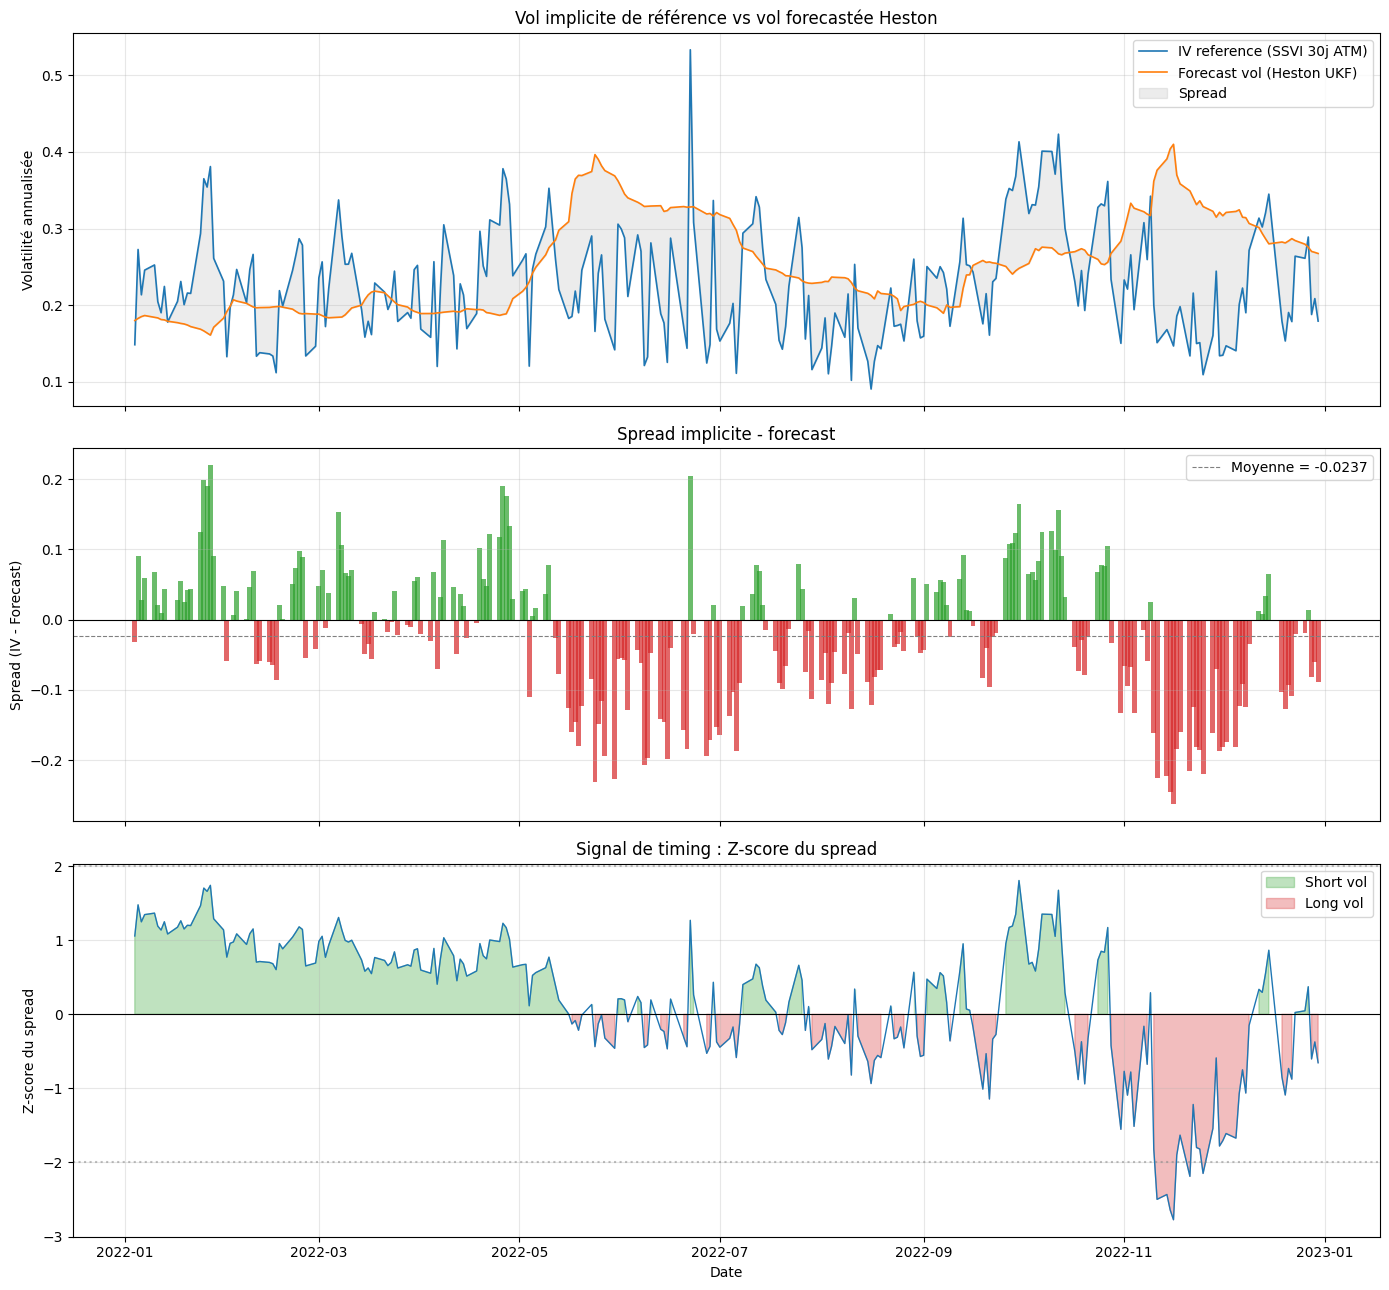

In [18]:
df_signal_plot = (
    df_spread.merge(
        df_allocation[["date", "ticker", "allocation", "spread_zscore"]],
        on=["date", "ticker"],
        how="inner",
    )
    .sort_values("date")
)

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

# IV vs Heston vol forecast
ax1 = axes[0]
ax1.plot(df_signal_plot["date"], df_signal_plot["iv_reference"], label="IV reference (SSVI 30j ATM)", linewidth=1.2)
ax1.plot(df_signal_plot["date"], df_signal_plot["forecast_volatility"], label="Forecast vol (Heston UKF)", linewidth=1.2)
ax1.fill_between(
    df_signal_plot["date"],
    df_signal_plot["iv_reference"],
    df_signal_plot["forecast_volatility"],
    alpha=0.15,
    color="gray",
    label="Spread",
)
ax1.set_ylabel("Volatilité annualisée")
ax1.legend(loc="upper right")
ax1.set_title("Vol implicite de référence vs vol forecastée Heston")
ax1.grid(alpha=0.3)

# Spread
ax2 = axes[1]
spread = df_signal_plot["spread"]
colors = ["tab:green" if s >= 0 else "tab:red" for s in spread]
ax2.bar(df_signal_plot["date"], spread, color=colors, width=1.5, alpha=0.7)
ax2.axhline(0.0, color="black", linewidth=0.8)
ax2.axhline(spread.mean(), color="gray", linestyle="--", linewidth=0.8, label=f"Moyenne = {spread.mean():.4f}")
ax2.set_ylabel("Spread (IV - Forecast)")
ax2.legend(loc="upper right")
ax2.set_title("Spread implicite - forecast")
ax2.grid(alpha=0.3)

# Z-score
ax3 = axes[2]
zscore = df_signal_plot["spread_zscore"]
ax3.plot(df_signal_plot["date"], zscore, color="tab:blue", linewidth=1.0)
ax3.fill_between(df_signal_plot["date"], zscore, 0, where=(zscore > 0), alpha=0.3, color="tab:green", label="Short vol")
ax3.fill_between(df_signal_plot["date"], zscore, 0, where=(zscore < 0), alpha=0.3, color="tab:red", label="Long vol")
ax3.axhline(0, color="black", linewidth=0.8)
ax3.axhline(2, color="gray", linestyle=":", alpha=0.5)
ax3.axhline(-2, color="gray", linestyle=":", alpha=0.5)
ax3.set_ylabel("Z-score du spread")
ax3.set_xlabel("Date")
ax3.legend(loc="upper right")
ax3.set_title("Signal de timing : Z-score du spread")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Generate strategies

In [19]:
VARIANCE_SWAP_LEG = [
    {
        "day_to_expiry_target": TARGET_DTE,
        "strike_spacing": 1,
        "weight": -1.0,
        "rebal_week_day": [2],  
    }
]

In [20]:
df_allocation["date"] = pd.to_datetime(df_allocation["date"])

In [21]:
# Generate var swap trades
df_trades_varswap = VarianceSwap.generate_trades(
    start_date=START_DATE,
    end_date=END_DATE,
    tickers=TICKER,
    legs=VARIANCE_SWAP_LEG,
)

# Var swap static
bt_static = BacktesterBidAskFromData(df_trades_varswap).compute_backtest()

# Var swap dynamic heston
df_trades_heston = DynamicAllocationOverlay.apply_to_trades(
    df_trades=df_trades_varswap,
    df_allocation=df_allocation,
    lag_business_days=1,
    allocation_col="allocation",
    fill_value=0.0,
)
bt_heston = BacktesterBidAskFromData(df_trades_heston).compute_backtest()

# Var swap dynamic naive
df_trades_naive = DynamicAllocationOverlay.apply_to_trades(
    df_trades=df_trades_varswap,
    df_allocation=df_allocation_naive,
    lag_business_days=1,
    allocation_col="allocation",
    fill_value=0.0,
)
bt_naive = BacktesterBidAskFromData(df_trades_naive).compute_backtest()

2026-04-05 22:04:39,623 - INFO - Loading option data from 2020-01-02 00:00:00 to 2022-12-30 00:00:00
2026-04-05 22:04:39,625 - INFO - Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-04-05 22:05:59,683 - INFO - Processing with {'ticker': 'AAPL'}
2026-04-05 22:05:59,790 - INFO - Potentially add extra field with None
2026-04-05 22:06:13,155 - INFO - Preprocessing option data.
2026-04-05 22:06:13,276 - INFO - Selecting options for leg: VARIANCE SWAP using the rules:
{'day_to_expiry_target': 30}


         spot  strike expiration    delta    gamma     vega    theta      rho  \
221    303.19   305.0 2020-02-07  0.48865  0.01568  0.35252 -0.16515  0.11811   
222    303.19   307.5 2020-02-07  0.44892  0.01560  0.34996 -0.16333  0.10915   
223    303.19   310.0 2020-02-07  0.41123  0.01538  0.34340 -0.15949  0.10018   
224    303.19   312.5 2020-02-07  0.37300  0.01506  0.33430 -0.15527  0.09078   
225    303.19   315.0 2020-02-07  0.33718  0.01460  0.32224 -0.14838  0.08259   
...       ...     ...        ...      ...      ...      ...      ...      ...   
42895  126.06   115.0 2023-01-27 -0.21161  0.01781  0.10606 -0.07381 -0.02409   
42896  126.06   120.0 2023-01-27 -0.31260  0.02296  0.12895 -0.08490 -0.03455   
42897  126.06   124.0 2023-01-27 -0.41069  0.02622  0.14175 -0.08979 -0.04476   
42898  126.06   125.0 2023-01-27 -0.43804  0.02700  0.14418 -0.08902 -0.04702   
42899  126.06   126.0 2023-01-27 -0.46479  0.02769  0.14555 -0.08821 -0.04991   

       implied_volatility  

C:\Users\33761\OneDrive - CentraleSupelec\Documents\Cours 4A\Stratégie de la volatilité\Code\Dauphine-Lecture-Volatility\investment_lab\option_trade.py:310: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df_group: cls._normalize_strike_weights(df_group, target_weight=weight))
2026-04-05 22:06:15,911 - INFO - Converting 8799 df_trades to daily time series
2026-04-05 22:06:21,444 - INFO - Forward filling option data for df
C:\Users\33761\OneDrive - CentraleSupelec\Documents\Cours 4A\Stratégie de la volatilité\Code\Dauphine-Lecture-Volatility\investment_lab\util.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version

In [22]:
# Var swap dynamic heston
df_trades_heston = DynamicAllocationOverlay.apply_to_trades(
    df_trades=df_trades_varswap,
    df_allocation=df_allocation,
    lag_business_days=1,
    allocation_col="allocation",
    fill_value=0.0,
)
bt_heston = BacktesterBidAskFromData(df_trades_heston).compute_backtest()

# Var swap dynamic naive
df_trades_naive = DynamicAllocationOverlay.apply_to_trades(
    df_trades=df_trades_varswap,
    df_allocation=df_allocation_naive,
    lag_business_days=1,
    allocation_col="allocation",
    fill_value=0.0,
)
bt_naive = BacktesterBidAskFromData(df_trades_naive).compute_backtest()

2026-04-05 22:13:26,091 - INFO - Shifting +1 business to ensure valid trading result.
2026-04-05 22:13:26,123 - INFO - Reading between 2020-01-08 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-04-05 22:14:46,680 - INFO - Processing with {'ticker': ['AAPL']}
2026-04-05 22:14:46,784 - INFO - Potentially add extra field with None
C:\Users\33761\OneDrive - CentraleSupelec\Documents\Cours 4A\Stratégie de la volatilité\Code\Dauphine-Lecture-Volatility\investment_lab\backtest.py:119: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
2026-04-05 22:15:08,588 - INFO - Forward filling option data for df
C:\Users\33761\OneDrive - CentraleSupelec\Documents\Cours 4A\Stratég

In [23]:
results = pd.DataFrame([
    evaluate_backtest(bt_static.nav, "var_swap_static"),
    evaluate_backtest(bt_heston.nav, "var_swap_dynamic_heston", df_allocation),
    evaluate_backtest(bt_naive.nav, "var_swap_dynamic_naive", df_allocation_naive),
])

results

,strategy,annual_return,annual_vol,max_drawdown,sharpe,calmar,hit_ratio,avg_turnover
0,var_swap_static,-0.069689,0.165491,-0.303083,-0.421106,-0.229935,0.368895,NaN
1,var_swap_dynamic_heston,0.005034,0.013539,-0.014912,0.371837,0.337610,0.043702,0.259772
2,var_swap_dynamic_naive,0.004700,0.017799,-0.023406,0.264073,0.200812,0.147815,0.250602


### Plot results

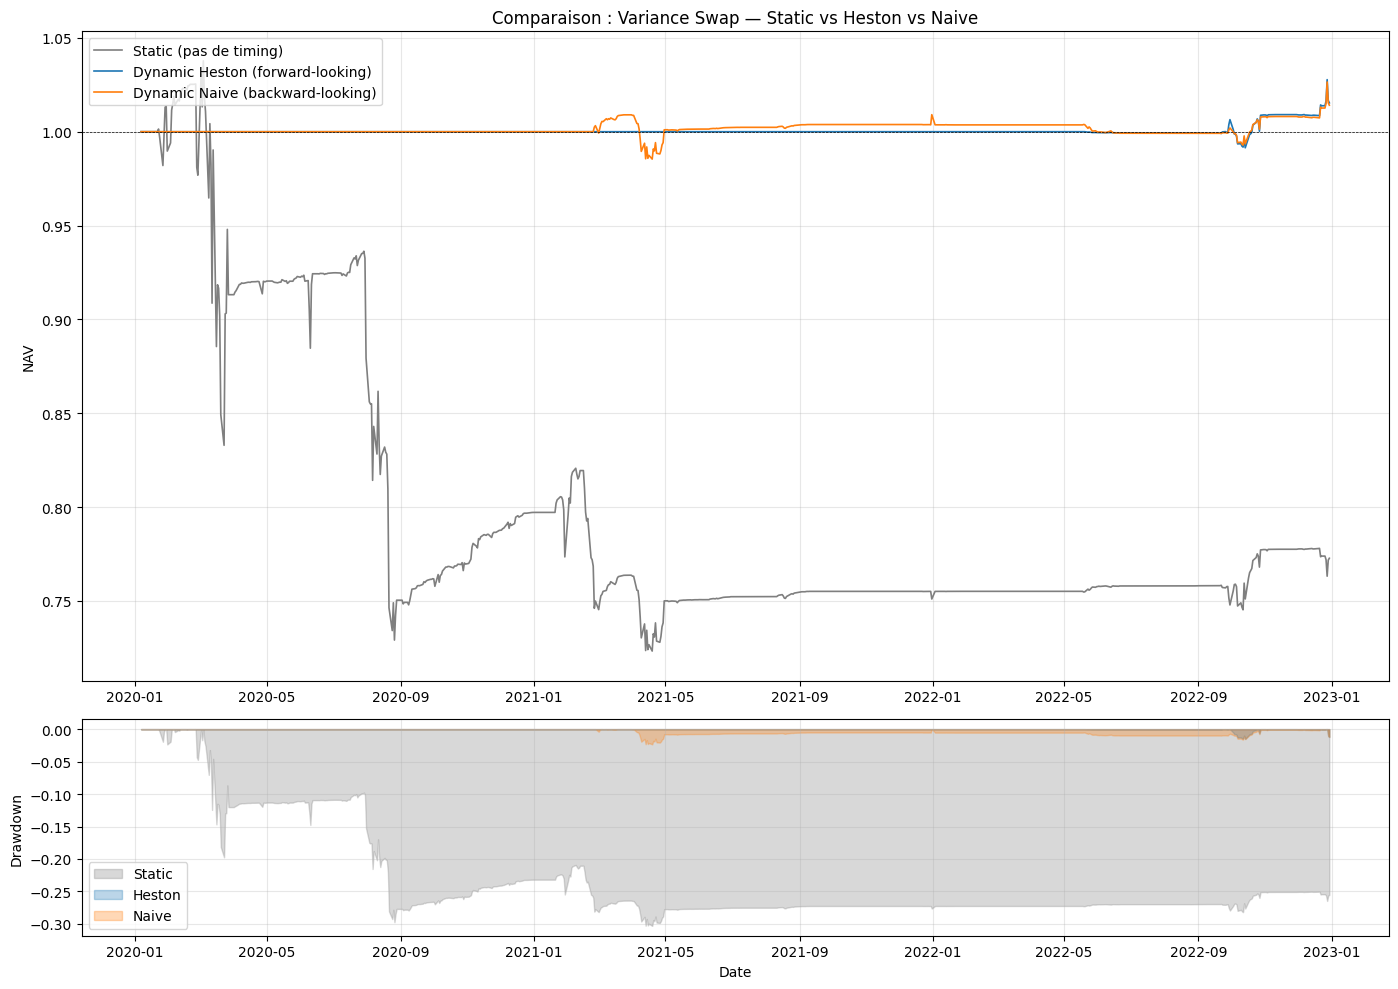

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

# NAV
ax1 = axes[0]
for name, bt, color in [
    ("Static (pas de timing)", bt_static, "tab:gray"),
    ("Dynamic Heston (forward-looking)", bt_heston, "tab:blue"),
    ("Dynamic Naive (backward-looking)", bt_naive, "tab:orange"),
]:
    nav = bt.nav["NAV"]
    ax1.plot(nav.index, nav.values, label=name, color=color, linewidth=1.2)

ax1.axhline(1.0, color="black", linewidth=0.5, linestyle="--")
ax1.set_ylabel("NAV")
ax1.set_title("Comparaison : Variance Swap — Static vs Heston vs Naive")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

# Drawdown
ax2 = axes[1]
for name, bt, color in [
    ("Static", bt_static, "tab:gray"),
    ("Heston", bt_heston, "tab:blue"),
    ("Naive", bt_naive, "tab:orange"),
]:
    nav = bt.nav["NAV"]
    dd = (nav / nav.cummax()) - 1
    ax2.fill_between(dd.index, dd.values, 0, alpha=0.3, color=color, label=name)

ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()



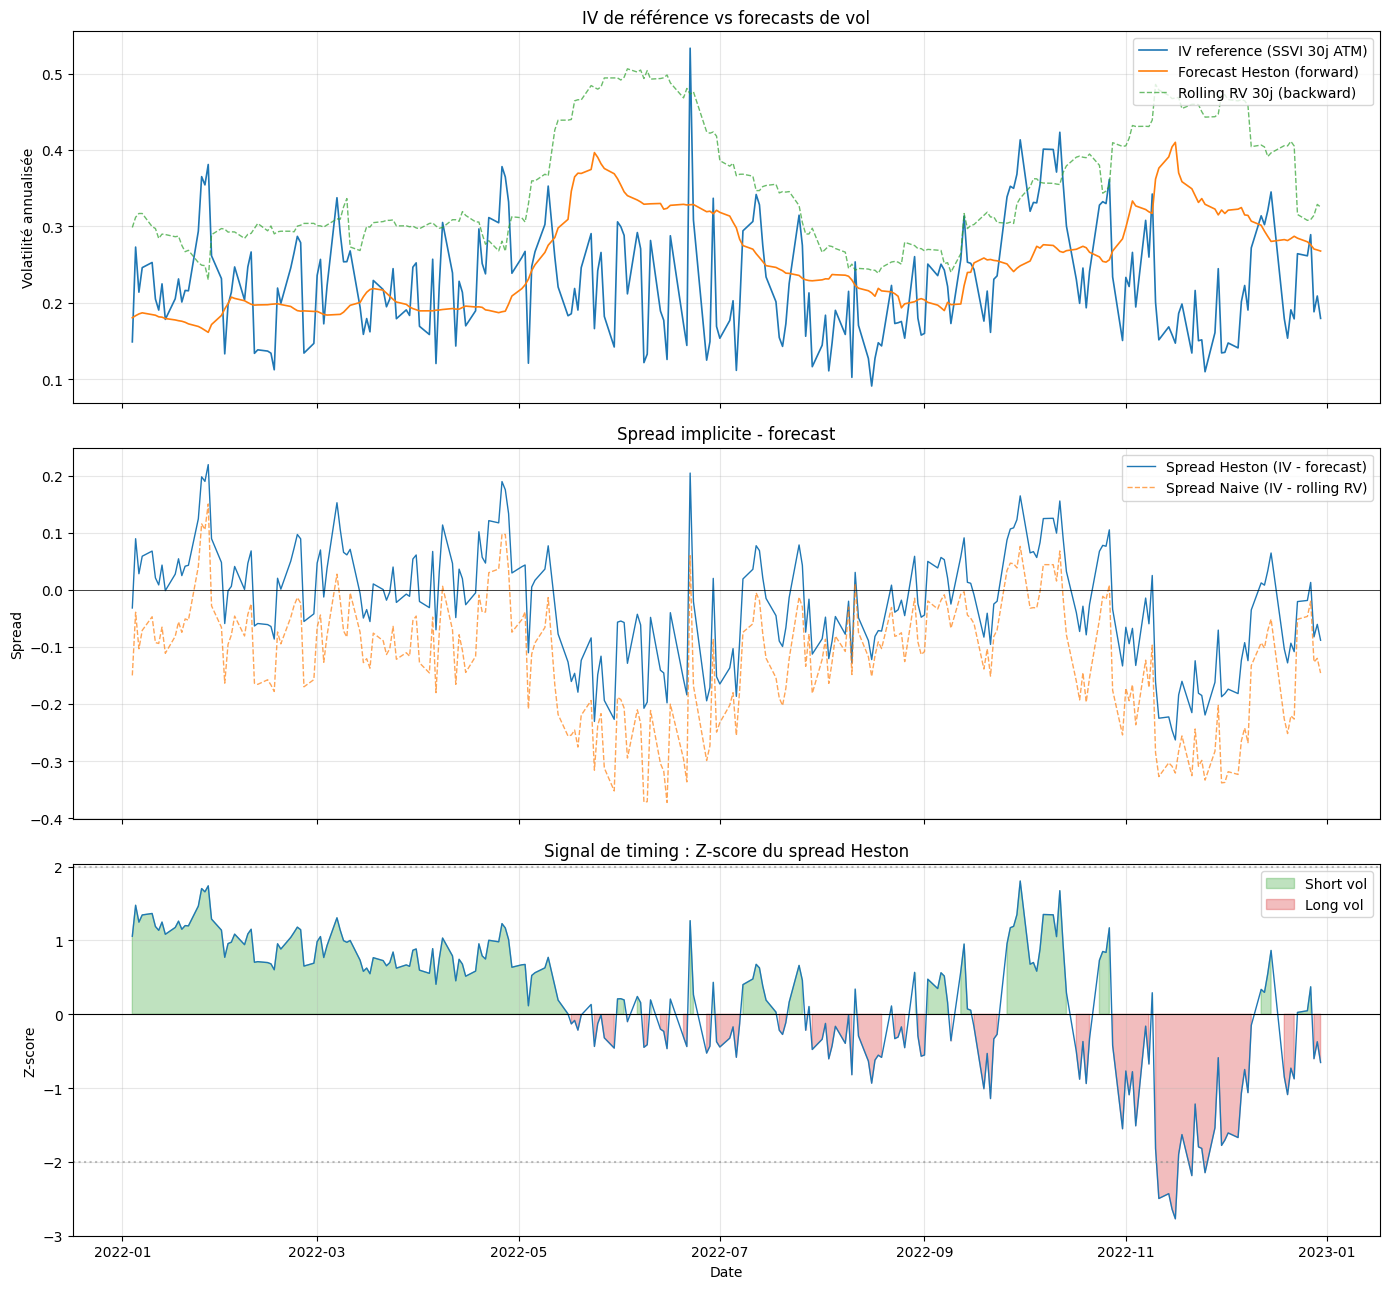

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

df_plot = (
    df_spread
    .merge(
        df_allocation[["date", "ticker", "allocation", "spread_zscore"]],
        on=["date", "ticker"], how="inner",
    )
    .sort_values("date")
)

# IV vs Heston vs Naive realized vol
ax1 = axes[0]
ax1.plot(df_plot["date"], df_plot["iv_reference"], label="IV reference (SSVI 30j ATM)", linewidth=1.2)
ax1.plot(df_plot["date"], df_plot["forecast_volatility"], label="Forecast Heston (forward)", linewidth=1.2)

# Realized vol naive
df_naive_plot = df_spread_naive[["date", "ticker", "rolling_realized_vol"]].copy()
df_plot_merged = df_plot.merge(df_naive_plot, on=["date", "ticker"], how="left")
ax1.plot(df_plot_merged["date"], df_plot_merged["rolling_realized_vol"],
         label="Rolling RV 30j (backward)", linewidth=1.0, linestyle="--", alpha=0.7)

ax1.set_ylabel("Volatilité annualisée")
ax1.legend(loc="upper right")
ax1.set_title("IV de référence vs forecasts de vol")
ax1.grid(alpha=0.3)

# Spread Heston vs Spread naive
ax2 = axes[1]
ax2.plot(df_plot["date"], df_plot["spread"], label="Spread Heston (IV - forecast)", linewidth=1.0)

df_naive_spread_plot = df_spread_naive[["date", "ticker", "spread"]].rename(columns={"spread": "spread_naive"})
df_plot_merged2 = df_plot.merge(df_naive_spread_plot, on=["date", "ticker"], how="left")
ax2.plot(df_plot_merged2["date"], df_plot_merged2["spread_naive"],
         label="Spread Naive (IV - rolling RV)", linewidth=1.0, linestyle="--", alpha=0.7)

ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("Spread")
ax2.legend(loc="upper right")
ax2.set_title("Spread implicite - forecast")
ax2.grid(alpha=0.3)

# Z-score Heston
ax3 = axes[2]
zscore = df_plot["spread_zscore"]
ax3.plot(df_plot["date"], zscore, color="tab:blue", linewidth=1.0)
ax3.fill_between(df_plot["date"], zscore, 0, where=(zscore > 0),
                 alpha=0.3, color="tab:green", label="Short vol")
ax3.fill_between(df_plot["date"], zscore, 0, where=(zscore < 0),
                 alpha=0.3, color="tab:red", label="Long vol")
ax3.axhline(0, color="black", linewidth=0.8)
ax3.axhline(2, color="gray", linestyle=":", alpha=0.5)
ax3.axhline(-2, color="gray", linestyle=":", alpha=0.5)
ax3.set_ylabel("Z-score")
ax3.set_xlabel("Date")
ax3.legend(loc="upper right")
ax3.set_title("Signal de timing : Z-score du spread Heston")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

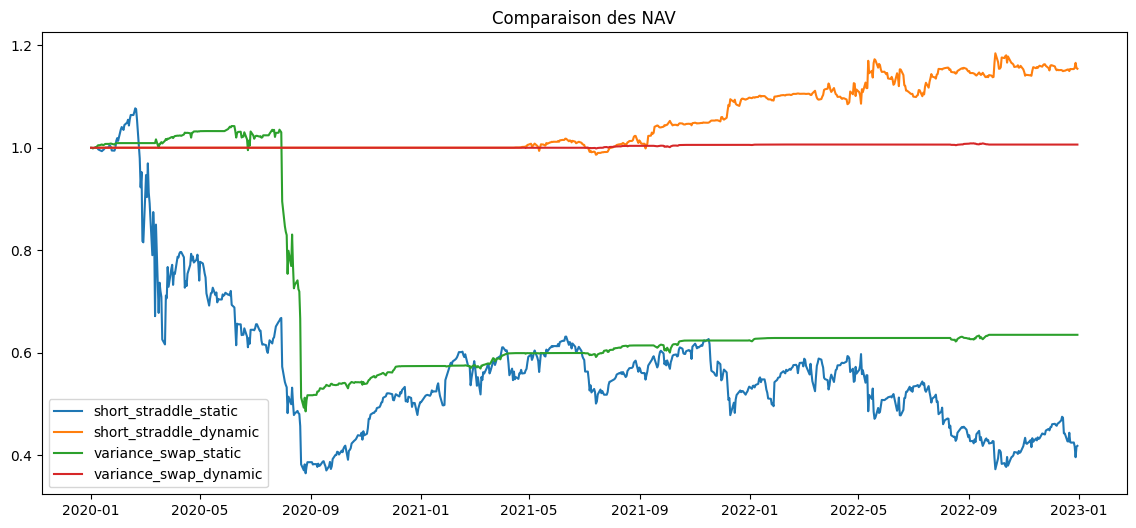